## **Iris Dataset: Classification with Cross-Validation**

### **About the data source**


The Iris flower data set, or Fisher's Iris data set, is a multivariate data set introduced by the British statistician, eugenicist, and biologist Ronald Fisher in his 1936 paper on the use of multiple measurements in taxonomic problems as an example of linear discriminant analysis.

His contribution to statistics goes far beyond Fisher's exact test. For example, he developed maximum likelihood estimation and the analysis of variance (more commonly known by its acronym ANOVA) test. For these important contributions, he is highly regarded in the history of modern statistics.


![https://miro.medium.com/max/1270/1*GiRsB7kVqXsbzdFejYMOHw.png](https://miro.medium.com/max/1270/1*GiRsB7kVqXsbzdFejYMOHw.png)

> Source: https://medium.com/@Nivitus./iris-flower-classification-machine-learning-d4e337140fa4

### **Classification algorithm in machine learning**


Classification is the process of recognizing, understanding, and grouping ideas and objects into preset categories or “sub-populations.” Using pre-categorized training datasets, machine learning programs use a variety of algorithms to classify future datasets into categories. Classification algorithms in machine learning use input training data to predict the likelihood that subsequent data will fall into one of the predetermined categories. One of the most common uses of classification is filtering emails into “spam” or “non-spam.” 

In short, classification is a form of “pattern recognition,” with classification algorithms applied to the training data to find the same pattern (similar words or sentiments, number sequences, etc.) in future sets of data.

![https://miro.medium.com/max/1400/1*-fniNC8gWI34qLAiBzgGZA.png](https://miro.medium.com/max/1400/1*-fniNC8gWI34qLAiBzgGZA.png)

> Source: https://www.edureka.co/blog/classification-in-machine-learning/

## **Let's start!**

In [1]:
# Import the required libraries
import seaborn as sns; sns.set()
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn import metrics

---
### **Data loading and initial review**

In [2]:
# Download data
df = pd.read_csv('../datasets/iris.csv') # https://www.kaggle.com/datasets/uciml/iris

In [3]:
# Dataset array dimension
df.shape

(150, 6)

In [4]:
# Basic information about the data set
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [5]:
# The first five rows of the data set
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
# The last five rows of the data set
df.tail()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


The dataset has 6 columns and 150 rows. The 2nd, 3rd, 4th and 5th columns are the dimensions of each element of the perianth in centimeters. The last column contains information about the species.

For further analysis we will not use column 1 (row numbering).

In [7]:
# Removal of the 'Id' column
df = df.drop('Id', axis = 1)

---
### **Data review**

In [8]:
# Table of records with gaps
df[df.isnull().any(axis = 1)]

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species


In [9]:
# Summary of number of records by species
df_part = df.groupby('Species').count()
df_part.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,
Iris-setosa,50,50,50,50
Iris-versicolor,50,50,50,50
Iris-virginica,50,50,50,50


The dataset contains no blank rows. The 150 rows of the dataset are divided into three equal parts (50 records each):

* measurement data of the species *Iris-setosa* perianth
* measurement data of the species *Iris-versicolor* perianth
* measurement data of the species *Iris-virginica* perianth

In [10]:
# Summary of average measurement value by species
df_mean = df.groupby('Species').mean()
df_mean.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


In [11]:
# Summary of maximum measurement value by species
df_max = df.groupby('Species').max()
df_max.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,
Iris-setosa,5.8,4.4,1.9,0.6
Iris-versicolor,7.0,3.4,5.1,1.8
Iris-virginica,7.9,3.8,6.9,2.5


In [12]:
# Summary of standard deviation values by species
df_std = df.groupby('Species').std()
df_std.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,
Iris-setosa,0.352490,0.381024,0.173511,0.107210
Iris-versicolor,0.516171,0.313798,0.469911,0.197753
Iris-virginica,0.635880,0.322497,0.551895,0.274650


The width and length of the sepals and petals do not exceed 8 cm. 

The length of the sepal is greater than that of the petals in each of the species analyzed. The longest sepal is usually found in the species *Iris-virginica*. The same is true for the length of the petals. 

The width of the sepal varies slightly between species. 

The species *Iris-setosa* has petals of the smallest width among the species analyzed. Moreover, this measurement is characterized by the smallest standard deviation, which indicates the low variability of this measurement among the examined specimens of this species.

In [13]:
# General statistical summary of width and length measurements
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


---
### **Data visualization**

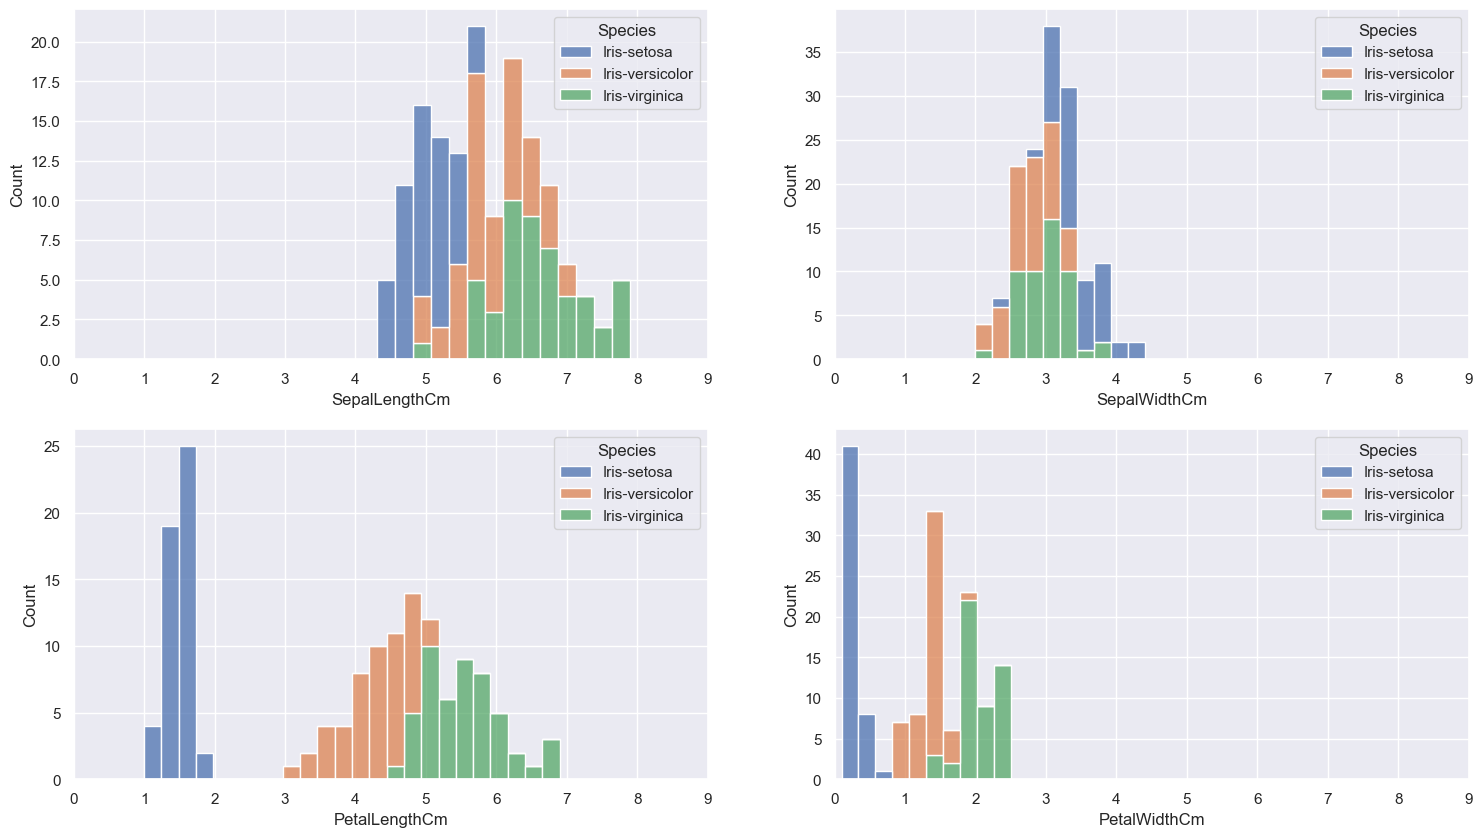

In [14]:
# Histograms
plt.figure(figsize = (18, 10))

plt.subplot(221)
sns.histplot(data = df, x = 'SepalLengthCm', hue = 'Species', binwidth = 0.25, multiple = 'stack')
plt.xlim(0, 9)

plt.subplot(222)
sns.histplot(data = df, x = 'SepalWidthCm', hue = 'Species', binwidth = 0.25, multiple = 'stack')
plt.xlim(0, 9)

plt.subplot(223)
sns.histplot(data = df, x = 'PetalLengthCm', hue = 'Species', binwidth = 0.25, multiple = 'stack')
plt.xlim(0, 9)

plt.subplot(224)
sns.histplot(data = df, x = 'PetalWidthCm', hue = 'Species', binwidth = 0.25, multiple = 'stack')
plt.xlim(0, 9)

plt.show()

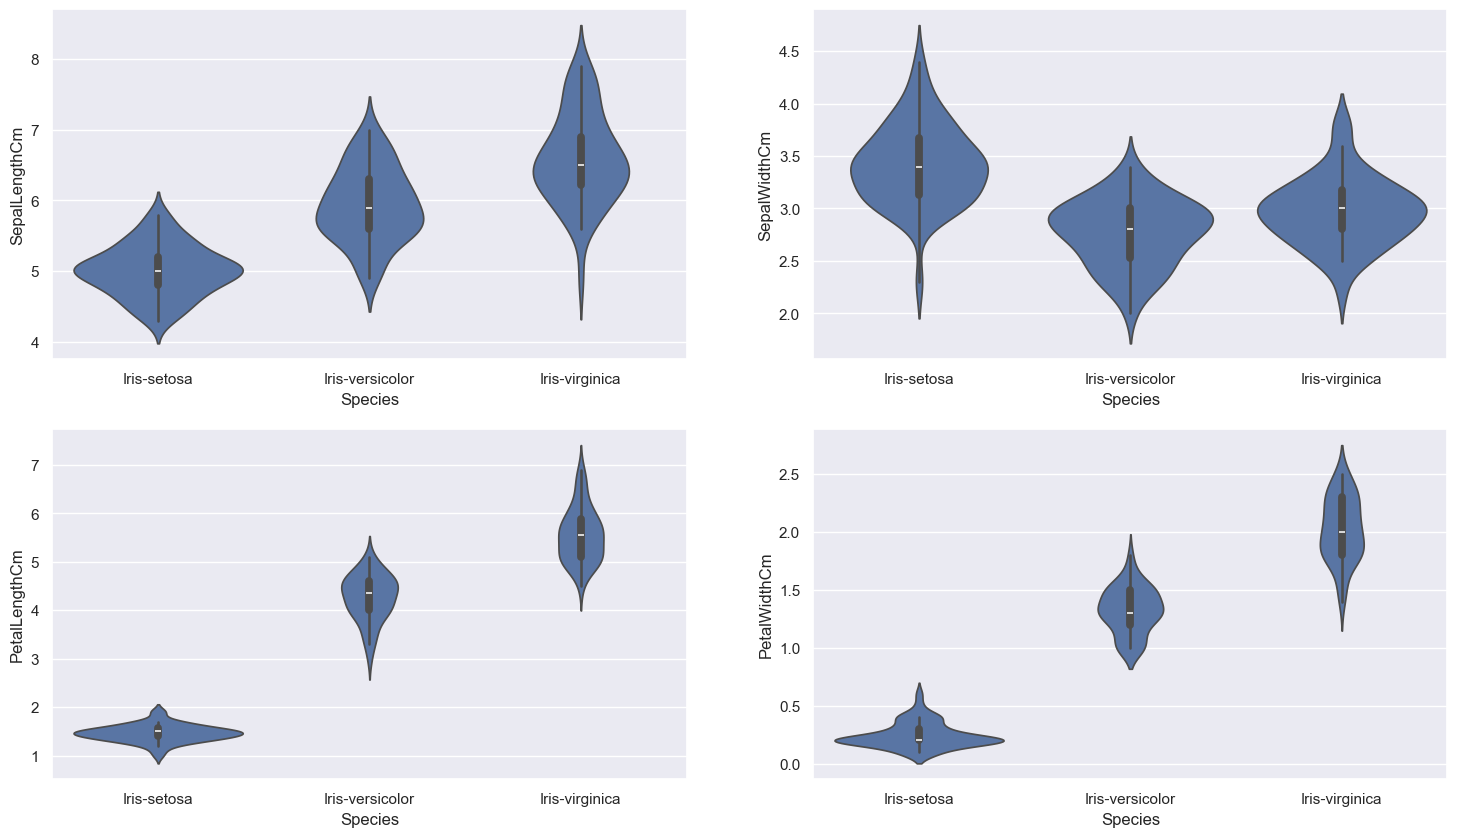

In [15]:
# Violin charts
plt.figure(figsize = (18, 10))

plt.subplot(221)
sns.violinplot(data = df, x = 'Species', y = 'SepalLengthCm')

plt.subplot(222)
sns.violinplot(data = df, x = 'Species', y = 'SepalWidthCm')

plt.subplot(223)
sns.violinplot(data = df, x = 'Species', y = 'PetalLengthCm')

plt.subplot(224)
sns.violinplot(data = df, x = 'Species', y = 'PetalWidthCm')

plt.show()

The range of sepal width and length is the same for individuals of all species. It is extremely difficult to distinguish between individuals based on these parameters alone.

The histogram and the violin plot concerning the length of the petal show very well the separation of the range of this parameter between the different species, i.e. *Iris-setosa* (about 1-2 cm), *Iris-versicolor* (about 3-5 cm), *Iris-virginica* (about 4-7 cm).

The last histogram and the violin plot show very well the small values of the petal widths of the analyzed iris species. The examined specimens of the species *Iris-setosa* have the smallest petal width.

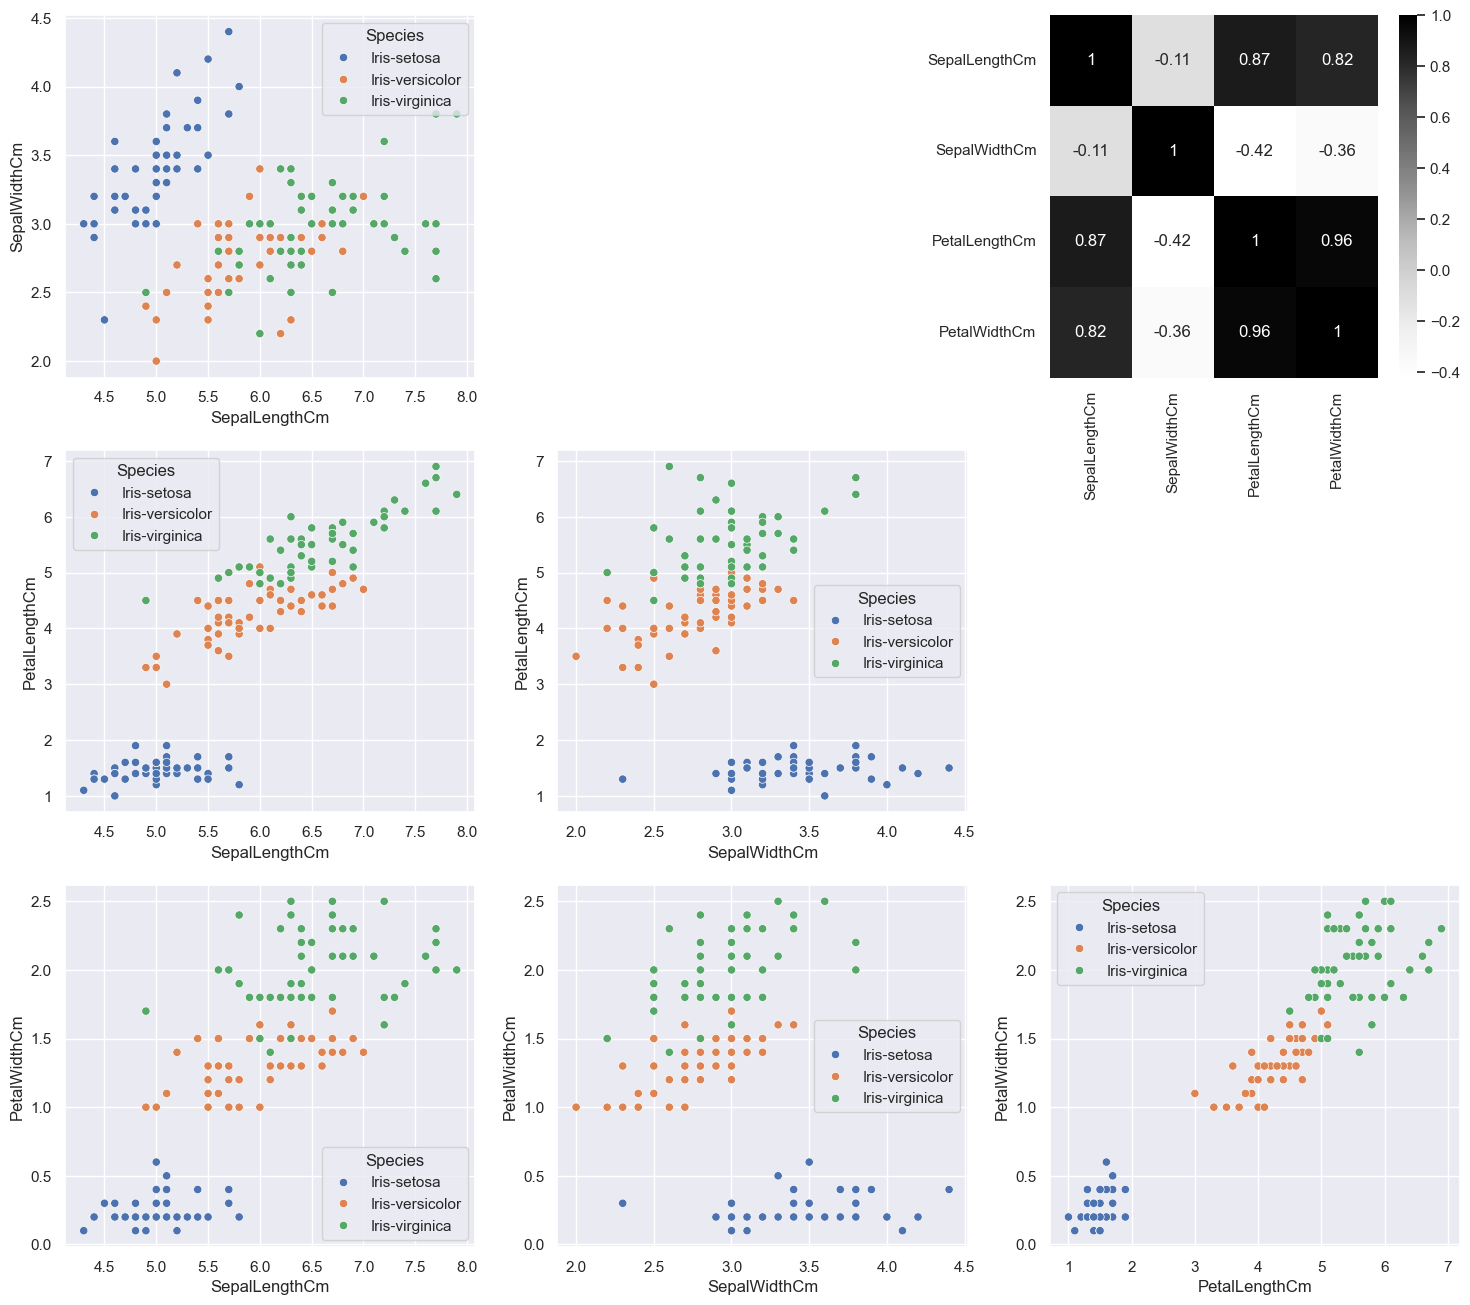

In [16]:
# Scatter plots (part 1)
plt.figure(figsize = (18, 16))

plt.subplot(331)
sns.scatterplot(data = df, x = 'SepalLengthCm', y = 'SepalWidthCm', hue = 'Species')

plt.subplot(333)
sns.heatmap(data = df.select_dtypes(include = 'number').corr(), annot = True, cmap = 'Greys')

plt.subplot(334)
sns.scatterplot(data = df, x = 'SepalLengthCm', y = 'PetalLengthCm', hue = 'Species')

plt.subplot(335)
sns.scatterplot(data = df, x = 'SepalWidthCm', y = 'PetalLengthCm', hue = 'Species')

plt.subplot(337)
sns.scatterplot(data = df, x = 'SepalLengthCm', y = 'PetalWidthCm', hue = 'Species')

plt.subplot(338)
sns.scatterplot(data = df, x = 'SepalWidthCm', y = 'PetalWidthCm', hue = 'Species')

plt.subplot(339)
sns.scatterplot(data = df, x = 'PetalLengthCm', y = 'PetalWidthCm', hue = 'Species')

plt.show()

There is a positive correlation between selected parameters studied. The measured data of individuals belonging to the species *Iris-setosa* differ significantly from the others. The correlation analysis is better performed separately for this series of data and for the remaining data (species: *Iris-versicolor* and *Iris-virginica*).

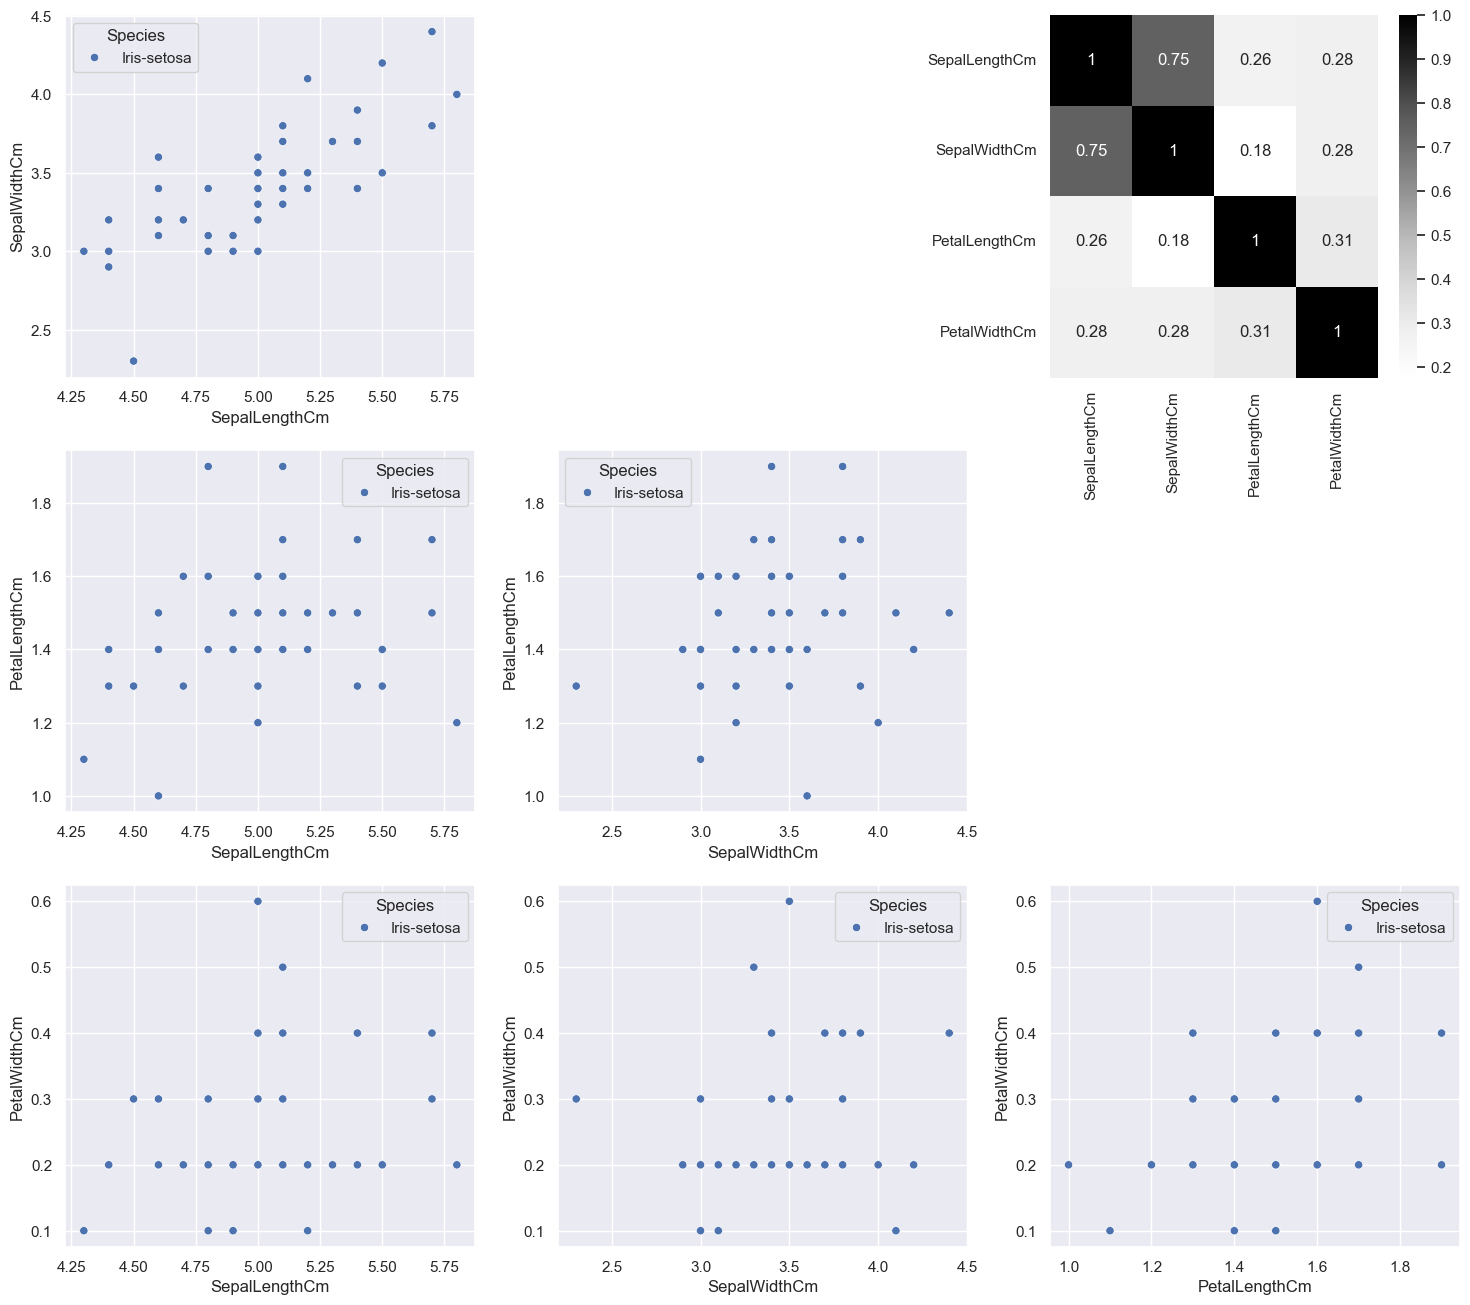

In [17]:
# Scatter plots (part 2)
plt.figure(figsize = (18, 16))

plt.subplot(331)
sns.scatterplot(data = df[df.Species == 'Iris-setosa'], x = 'SepalLengthCm', y = 'SepalWidthCm', hue = 'Species')

plt.subplot(333)
sns.heatmap(data = df[df.Species == 'Iris-setosa'].select_dtypes(include = 'number').corr(), annot = True, cmap = 'Greys')

plt.subplot(334)
sns.scatterplot(data = df[df.Species == 'Iris-setosa'], x = 'SepalLengthCm', y = 'PetalLengthCm', hue = 'Species')

plt.subplot(335)
sns.scatterplot(data = df[df.Species == 'Iris-setosa'], x = 'SepalWidthCm', y = 'PetalLengthCm', hue = 'Species')

plt.subplot(337)
sns.scatterplot(data = df[df.Species == 'Iris-setosa'], x = 'SepalLengthCm', y = 'PetalWidthCm', hue = 'Species')

plt.subplot(338)
sns.scatterplot(data = df[df.Species == 'Iris-setosa'], x = 'SepalWidthCm', y = 'PetalWidthCm', hue = 'Species')

plt.subplot(339)
sns.scatterplot(data = df[df.Species == 'Iris-setosa'], x = 'PetalLengthCm', y = 'PetalWidthCm', hue = 'Species')

plt.show()

In the case of specimens of the species *Iris-setosa*, only a positive correlation between the length and width of the sepal was observed. There is no correlation between the other parameters.

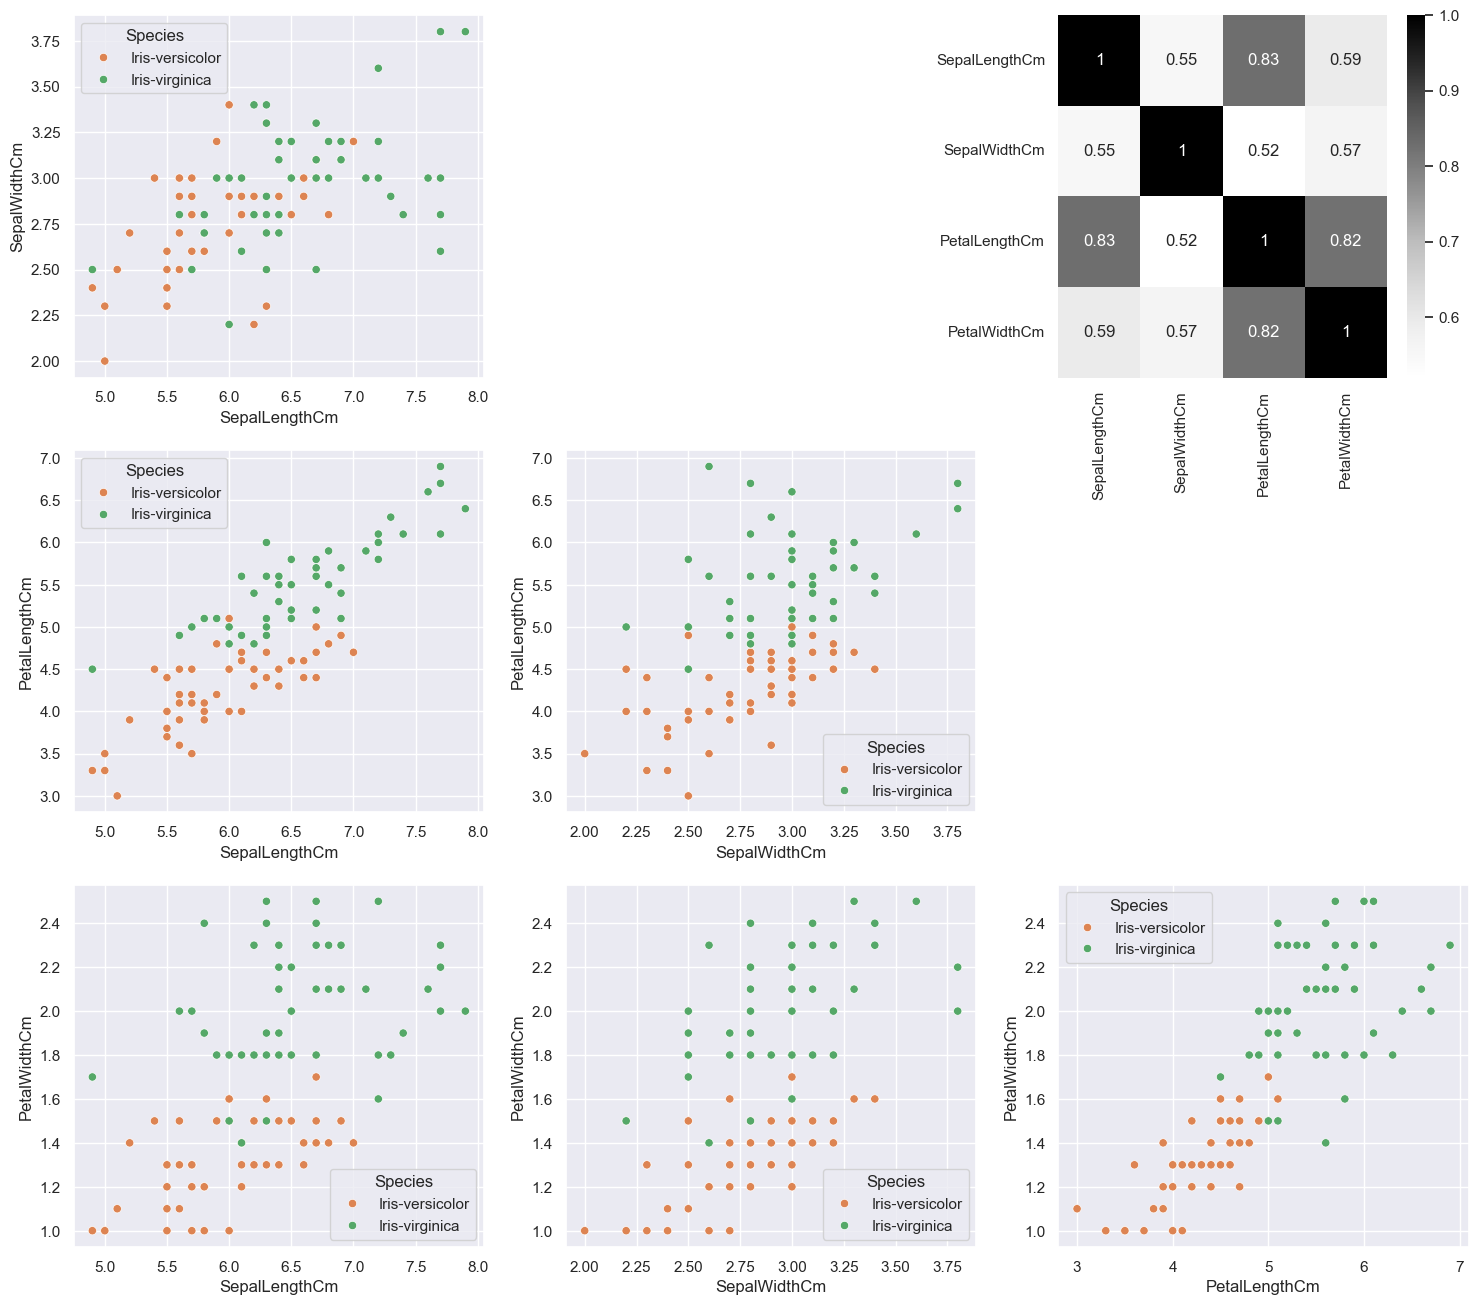

In [18]:
# Scatter plots (part 3)
plt.figure(figsize = (18, 16))
color = ['#dd8452', '#55a868']

plt.subplot(331)
sns.scatterplot(data = df[df.Species != 'Iris-setosa'], x = 'SepalLengthCm', y = 'SepalWidthCm', hue = 'Species', palette = color)

plt.subplot(333)
sns.heatmap(data = df[df.Species != 'Iris-setosa'].select_dtypes(include = 'number').corr(), annot = True, cmap = 'Greys')

plt.subplot(334)
sns.scatterplot(data = df[df.Species != 'Iris-setosa'], x = 'SepalLengthCm', y = 'PetalLengthCm', hue = 'Species', palette = color)

plt.subplot(335)
sns.scatterplot(data = df[df.Species != 'Iris-setosa'], x = 'SepalWidthCm', y = 'PetalLengthCm', hue = 'Species', palette = color)

plt.subplot(337)
sns.scatterplot(data = df[df.Species != 'Iris-setosa'], x = 'SepalLengthCm', y = 'PetalWidthCm', hue = 'Species', palette = color)

plt.subplot(338)
sns.scatterplot(data = df[df.Species != 'Iris-setosa'], x = 'SepalWidthCm', y = 'PetalWidthCm', hue = 'Species', palette = color)

plt.subplot(339)
sns.scatterplot(data = df[df.Species != 'Iris-setosa'], x = 'PetalLengthCm', y = 'PetalWidthCm', hue = 'Species', palette = color)

plt.show()

The data for the other two species i.e. *Iris-versicolor* and *Iris-virginica* are similar. There is a noticeable correlation between sepal length and petal length, but also between petal length and width. In the other parameter combinations the correlation is weak.

---
### **Classification algorithms**

Before using machine learning algorithms for classification, species names (words) should be converted to numerical designations (numbers).

In [19]:
# Change species names to numerical labels
df['Species'] = df['Species'].replace(['Iris-setosa'], 0)
df['Species'] = df['Species'].replace(['Iris-versicolor'], 1)
df['Species'] = df['Species'].replace(['Iris-virginica'], 2)
df['Species'] = df['Species'].astype(int)

In [20]:
# Examples of table rows with species names changed to numerical designations
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [21]:
# Set up the data set for machine learning algorithms
X_data = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y_data = df['Species']

In [22]:
# Split the data set into test and training sets
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size = 1/3)

#### **Decision Tree**
Machine Learning > Supervised Learning > Classification > Decision Tree

> Take a look: https://scikit-learn.org/stable/modules/tree.html

In [23]:
from sklearn.tree import DecisionTreeClassifier

In [24]:
# Selection of the <splitter> parameter
tree_val_result = []

for splitter in ['best', 'random']:
    tree_val_model = DecisionTreeClassifier(splitter = splitter, random_state = 42)
    tree_val_scores = cross_val_score(
        tree_val_model, 
        X_train, 
        y_train, 
        cv = RepeatedKFold(n_splits = 5, n_repeats = 15, random_state = 42)
    )
    
    tree_val_result.append([
        splitter, 
        np.round(np.mean(tree_val_scores), 3), 
        np.round(np.std(tree_val_scores), 3)
    ])

In [25]:
tree_val_result = pd.DataFrame(
    tree_val_result, 
    columns = ['Parameter <splitter>', 'Model accuracy', 'Standard deviation of the result'])

tree_val_result

,Parameter <splitter>,Model accuracy,Standard deviation of the result
0,best,0.933,0.053
1,random,0.917,0.065


Slightly better classification results were obtained with the default model settings. The results obtained with the test data set are shown below.

In [26]:
# Model settings
tree_model = DecisionTreeClassifier().fit(X_train, y_train)

# Predict results for the test set
y_pred = tree_model.predict(X_test)

In [27]:
# Classification evaluation
tree_raport = metrics.classification_report(y_test, y_pred, target_names = ['Iris-setosa (0)', 'Iris-versicolor (1)', 'Iris-virginica (2)'])
print(tree_raport)

                     precision    recall  f1-score   support

    Iris-setosa (0)       1.00      1.00      1.00        17
Iris-versicolor (1)       1.00      0.94      0.97        17
 Iris-virginica (2)       0.94      1.00      0.97        16

           accuracy                           0.98        50
          macro avg       0.98      0.98      0.98        50
       weighted avg       0.98      0.98      0.98        50



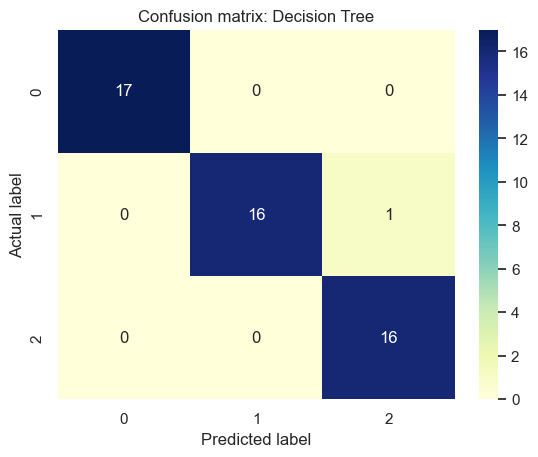

In [28]:
tree_cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
tree_cnf_plot = sns.heatmap(pd.DataFrame(tree_cnf_matrix), annot = True, cmap = 'YlGnBu')

plt.title('Confusion matrix: Decision Tree')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

#### **Nearest Neighbors Algorithm**
Machine Learning > Supervised Learning > Classification > K-NN

> Take a look: https://scikit-learn.org/stable/modules/neighbors.html

In [29]:
from sklearn.neighbors import KNeighborsClassifier

In [30]:
# Selection of the <n_neighbors> parameter
knn_val_result = []

for n_neighbors in range(1, 25):
    knn_val_model = KNeighborsClassifier(n_neighbors=n_neighbors)
    
    knn_val_scores = cross_val_score(
        knn_val_model, 
        X_train, 
        y_train, 
        cv = RepeatedKFold(n_splits=5, n_repeats=15, random_state=42)
    )
    
    knn_val_result.append([
        n_neighbors,
        np.round(np.mean(knn_val_scores), 3),
        np.round(np.std(knn_val_scores), 3)
    ])

In [31]:
knn_val_result = pd.DataFrame(
    knn_val_result, 
    columns = ['Parameter <n_neighbors>', 'Model accuracy', 'Standard deviation of the result'])

knn_val_result

,Parameter <n_neighbors>,Model accuracy,Standard deviation of the result
0,1,0.942,0.050
1,2,0.937,0.050
2,3,0.952,0.046
3,4,0.945,0.053
4,5,0.951,0.042
5,6,0.947,0.045
6,7,0.963,0.038
7,8,0.960,0.041
8,9,0.963,0.035
9,10,0.947,0.052


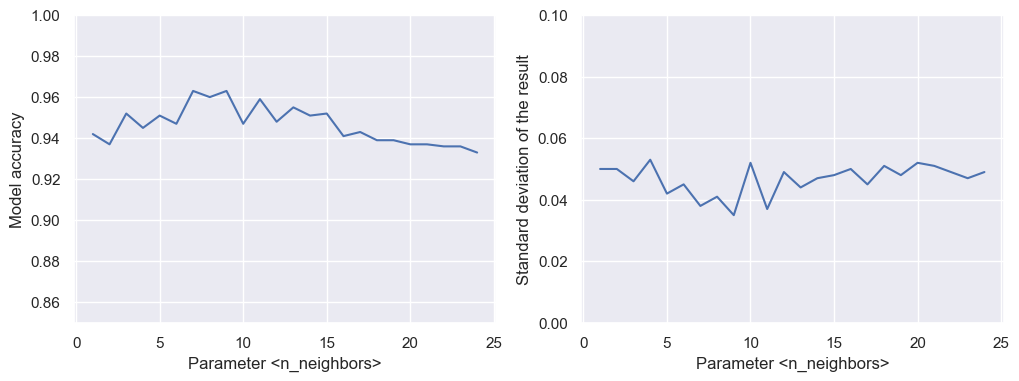

In [32]:
plt.figure(figsize = (12, 4))

plt.subplot(121)
sns.lineplot(data = knn_val_result, x = 'Parameter <n_neighbors>', y = 'Model accuracy')
plt.ylim(0.85, 1.00)

plt.subplot(122)
sns.lineplot(data = knn_val_result, x = 'Parameter <n_neighbors>', y = 'Standard deviation of the result')
plt.ylim(0.00, 0.10)

plt.show()

The accuracy of the model at the level above 94% is obtained, among other things, for the default values of the *n_neighbors* parameter. The model was left with the default settings.

In [33]:
# Model settings
knn_model = KNeighborsClassifier().fit(X_train, y_train)

# Predict results for the test set
y_pred = knn_model.predict(X_test)

In [34]:
# Classification evaluation
knn_raport = metrics.classification_report(y_test, y_pred, target_names = ['Iris-setosa (0)', 'Iris-versicolor (1)', 'Iris-virginica (2)'])
print(knn_raport)

                     precision    recall  f1-score   support

    Iris-setosa (0)       1.00      1.00      1.00        17
Iris-versicolor (1)       1.00      0.94      0.97        17
 Iris-virginica (2)       0.94      1.00      0.97        16

           accuracy                           0.98        50
          macro avg       0.98      0.98      0.98        50
       weighted avg       0.98      0.98      0.98        50



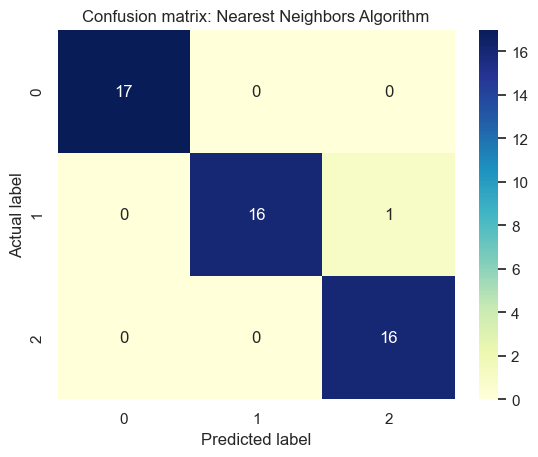

In [35]:
knn_cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
knn_cnf_plot = sns.heatmap(pd.DataFrame(knn_cnf_matrix), annot = True, cmap = 'YlGnBu')

plt.title('Confusion matrix: Nearest Neighbors Algorithm')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

#### **Support Vector Machines**
Machine Learning > Supervised Learning > Classification > Support Vector Machines

> Take a look: http://scikit-learn.org/stable/modules/svm.html

In [36]:
from sklearn.svm import SVC

In [37]:
# Selection of the <degree> parameter
svc_val_result = []

for degree in range(1, 6):
    svc_val_model = SVC(kernel = 'poly', degree = degree, random_state = 42)
    
    svc_val_scores = cross_val_score(
        svc_val_model, 
        X_train, 
        y_train, 
        cv = RepeatedKFold(n_splits = 5, n_repeats = 15, random_state = 42)
    )
    
    svc_val_result.append([
        degree,
        np.round(np.mean(svc_val_scores), 3),
        np.round(np.std(svc_val_scores), 3)
    ])

In [38]:
svc_val_result = pd.DataFrame(
    svc_val_result, 
    columns = ['Parameter <degree>', 'Model accuracy', 'Standard deviation of the result'])

svc_val_result

,Parameter <degree>,Model accuracy,Standard deviation of the result
0,1,0.941,0.051
1,2,0.969,0.038
2,3,0.958,0.042
3,4,0.961,0.042
4,5,0.955,0.046


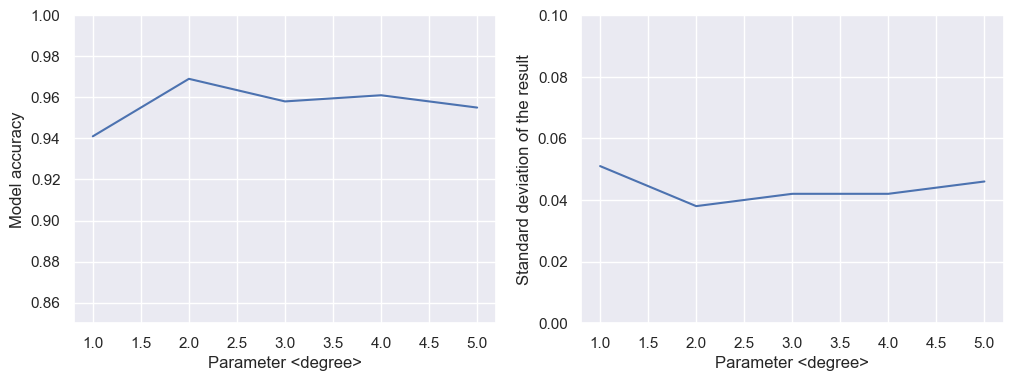

In [39]:
plt.figure(figsize = (12, 4))

plt.subplot(121)
sns.lineplot(data = svc_val_result, x = 'Parameter <degree>', y = 'Model accuracy')
plt.ylim(0.85, 1.00)

plt.subplot(122)
sns.lineplot(data = svc_val_result, x = 'Parameter <degree>', y = 'Standard deviation of the result')
plt.ylim(0.00, 0.10)

plt.show()

The 'poly' SVM algorithm obtains the best results for *degree* parameter settings of 2.

In [40]:
# Model settings
svm_model = SVC(kernel = 'poly', degree = 2).fit(X_train, y_train)

# Predict results for the test set
y_pred = svm_model.predict(X_test)

In [41]:
# Classification evaluation
svm_raport = metrics.classification_report(y_test, y_pred, target_names = ['Iris-setosa (0)', 'Iris-versicolor (1)', 'Iris-virginica (2)'])
print(svm_raport)

                     precision    recall  f1-score   support

    Iris-setosa (0)       1.00      1.00      1.00        17
Iris-versicolor (1)       1.00      0.94      0.97        17
 Iris-virginica (2)       0.94      1.00      0.97        16

           accuracy                           0.98        50
          macro avg       0.98      0.98      0.98        50
       weighted avg       0.98      0.98      0.98        50



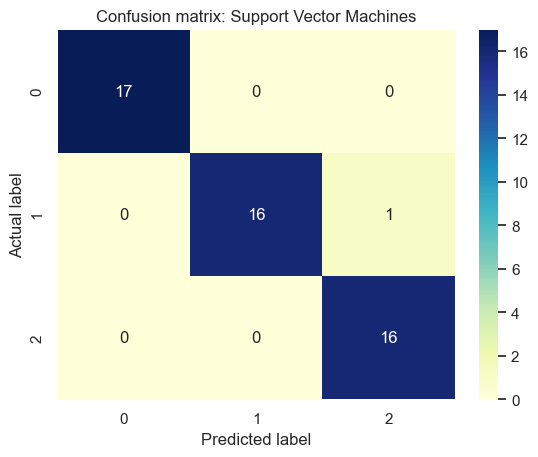

In [42]:
svm_cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
svm_cnf_plot = sns.heatmap(pd.DataFrame(svm_cnf_matrix), annot = True, cmap = 'YlGnBu')

plt.title('Confusion matrix: Support Vector Machines')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

#### **Neural Network Models**
Machine Learning > Supervised Learning > Classification > Neural Network Models

> Take a look: http://scikit-learn.org/stable/modules/neural_networks_supervised.html

In [43]:
from sklearn.neural_network import MLPClassifier

In [44]:
# Selection of the <hidden_layer_sizes> parameter
mlp_val_result = []

for hidden_size in range(25, 250, 25):
    mlp_val_model = MLPClassifier(
        max_iter = 8000, 
        hidden_layer_sizes = hidden_size,
        random_state = 42
    )
    
    mlp_val_scores = cross_val_score(
        mlp_val_model, 
        X_train, 
        y_train, 
        cv = RepeatedKFold(n_splits = 5, n_repeats = 15, random_state = 42)
    )
    
    mlp_val_result.append([
        hidden_size,
        np.round(np.mean(mlp_val_scores), 3),
        np.round(np.std(mlp_val_scores), 3)
    ])

In [45]:
mlp_val_result = pd.DataFrame(
    mlp_val_result, 
    columns = ['Parameter <hidden_layer_sizes>', 'Model accuracy', 'Standard deviation of the result'])

mlp_val_result

,Parameter <hidden_layer_sizes>,Model accuracy,Standard deviation of the result
0,25,0.973,0.038
1,50,0.966,0.041
2,75,0.964,0.040
3,100,0.967,0.040
4,125,0.965,0.041
5,150,0.967,0.038
6,175,0.967,0.041
7,200,0.967,0.041
8,225,0.967,0.040


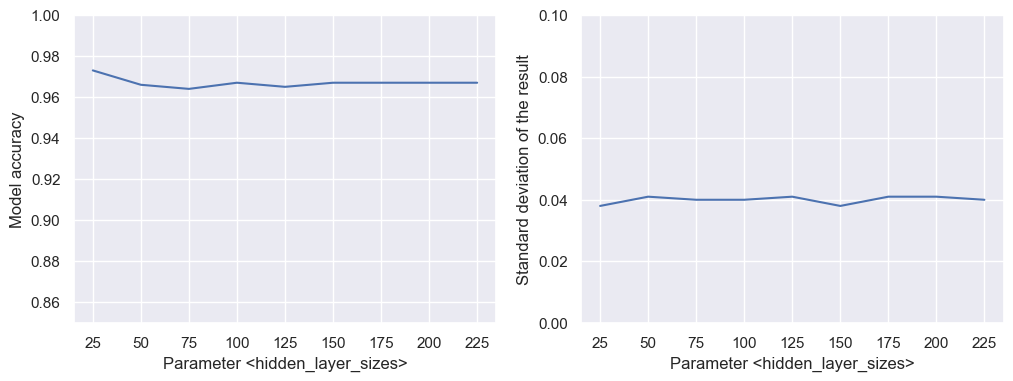

In [46]:
plt.figure(figsize = (12, 4))

plt.subplot(121)
sns.lineplot(data = mlp_val_result, x = 'Parameter <hidden_layer_sizes>', y = 'Model accuracy')
plt.ylim(0.85, 1.00)

plt.subplot(122)
sns.lineplot(data = mlp_val_result, x = 'Parameter <hidden_layer_sizes>', y = 'Standard deviation of the result')
plt.ylim(0.00, 0.10)

plt.show()

The accuracy of the classification model based on the neural network algorithm does not change significantly depending on the settings of the parameter *hidden_layer_sizes* (in the analysed case). The default settings of the model were left for further work with the test set.

In [47]:
# Model settings
mlp = MLPClassifier(max_iter = 8000).fit(X_train, y_train)

# Predict results for the test set
y_pred = mlp.predict(X_test)

In [48]:
# Classification evaluation
mlp_raport = metrics.classification_report(y_test, y_pred, target_names = ['Iris-setosa (0)', 'Iris-versicolor (1)', 'Iris-virginica (2)'])
print(mlp_raport)

                     precision    recall  f1-score   support

    Iris-setosa (0)       1.00      1.00      1.00        17
Iris-versicolor (1)       1.00      0.94      0.97        17
 Iris-virginica (2)       0.94      1.00      0.97        16

           accuracy                           0.98        50
          macro avg       0.98      0.98      0.98        50
       weighted avg       0.98      0.98      0.98        50



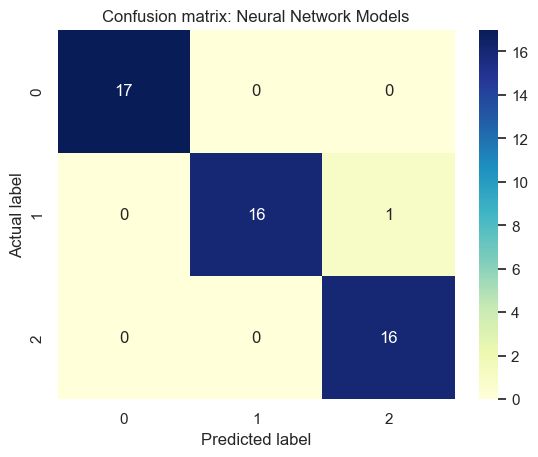

In [49]:
mlp_cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_plot = sns.heatmap(pd.DataFrame(mlp_cnf_matrix), annot = True, cmap = 'YlGnBu')

plt.title('Confusion matrix: Neural Network Models')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

---
## **Summary**

* Significant differences in the structure of the perianth of *Iris-setosa* compared to the other analyzed species allow to obtain very good classification results for this species. Each of the classification models used assigned *Iris-setosa* individuals from the test set to this species with 100% accuracy.

* The classification process based only on sepal length data would have been considerably hampered by the slight variation of this parameter in the analyzed iris species.

* Each of the classification algorithms used has an accuracy of at least 90%.